In [1]:
import sys
from pathlib import Path
import torch

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
%load_ext autoreload
%autoreload 2

import random
import numpy as np
import pandas as pd
import torch

import Python.config as cfg
import Python.utils as ut
import Python.simfun as sim
import Python.model2 as md
import Python.metric as me
import Python.bnn_mcmc as mcmc
import Python.bnn_train as train

seed = 123
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

X, y, feature_true, signal, sim_info = sim.simfun_nonlinear(
    n=160,
    p=1,
    n_active=1,
    interaction=False,
    seed=seed,
    device=device,
)

In [3]:
# -----------------------------
# 1. Split data and make grids
# -----------------------------

split_cfg = cfg.SplitConfig(
    train_frac=0.60,
    val_frac=0.20,
    test_frac=0.20,
    seed=seed,
)

indices = ut.make_split(X.shape[0], split_cfg)
splits = ut.split_data(X, y, indices, mode="tensor")
signal_splits = ut.split_data(X, signal, indices, mode="tensor")

X_train = splits["X_train"]
y_train = splits["y_train"]
X_test = splits["X_test"]
signal_test = signal_splits["y_test"]

x_val_grid = torch.linspace(
    -torch.pi, torch.pi, 201, device=device, dtype=X_train.dtype
)[:, None]
signal_val_grid = torch.cos(x_val_grid[:, 0])

x_grid = torch.linspace(
    -torch.pi, torch.pi, 400, device=device, dtype=X_train.dtype
)[:, None]
signal_grid = torch.cos(x_grid[:, 0])

In [4]:
# -----------------------------------------
# 2. One-block edge model with mixed gates
# -----------------------------------------

arch = dict(
    input_dim=1,
    d_model=2,
    n_blocks=1,
    ffn_dims=3,
    out_dim=1,
    bounded=None,
    gate_power=2.0,
    gate_tau=1.0,
    sigmoid_params=("E", "Wout"),
    sigmoid_tau=1.0,
    attention_type="none",
    ffn_activation="relu",
)

mcmc_model = md.LaSTBNNVI(
    X=X_train,
    y=y_train,
    family=sim_info["family"],
    sigma2=sim_info["sigma2"],
    init_sd=0.5,
    K_flow=0,
    **arch,
).to(device)

xi_zero = torch.zeros(1, mcmc_model.decoder.dim, device=device)
_, gate_zero = mcmc_model.decoder.unpack(
    xi_zero, return_summary=True
)

assert torch.allclose(gate_zero["E_gate_mean"], torch.full_like(gate_zero["E_gate_mean"], 0.5))
assert torch.allclose(gate_zero["Wout_gate_mean"], torch.full_like(gate_zero["Wout_gate_mean"], 0.5))
assert torch.all(gate_zero["W1_0_gate_mean"] == 0)

print(gate_zero["gate_type_by_parameter"])

{'E': 'sigmoid', 'e': 'normalized_repu', 'W1_0': 'normalized_repu', 'b1_0': 'normalized_repu', 'W2_0': 'normalized_repu', 'b2_0': 'normalized_repu', 'Wout': 'sigmoid', 'bout': 'normalized_repu'}


e:\positron\NFlow\Python\model2.py:488: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\ReduceOps.cpp:1760.)
  val.std(dim=0)
e:\positron\NFlow\Python\model2.py:493: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\ReduceOps.cpp:1760.)
  summary["t_sd"] = t.std(dim=0)


In [5]:
# -----------------------------
# 3. Shared-likelihood MCMC
# -----------------------------

mcmc_ref = mcmc.run_bnn_mcmc(
    model=mcmc_model,
    N=10000,
    S_max=100,
    burnin=2000,
    thin=1,
    seed=seed,
    print_every=500,
)

mcmc_xi = torch.as_tensor(
    mcmc_ref["xi_draws"],
    device=device,
    dtype=X_train.dtype,
)

mcmc_iter=00001 loglik=-179.134
mcmc_iter=00500 loglik=-140.065
mcmc_iter=01000 loglik=-141.168
mcmc_iter=01500 loglik=-142.341
mcmc_iter=02000 loglik=-141.600
mcmc_iter=02500 loglik=-140.034
mcmc_iter=03000 loglik=-140.421
mcmc_iter=03500 loglik=-139.654
mcmc_iter=04000 loglik=-141.241
mcmc_iter=04500 loglik=-141.567
mcmc_iter=05000 loglik=-140.985
mcmc_iter=05500 loglik=-144.615
mcmc_iter=06000 loglik=-141.363
mcmc_iter=06500 loglik=-143.645
mcmc_iter=07000 loglik=-141.557
mcmc_iter=07500 loglik=-140.370
mcmc_iter=08000 loglik=-140.261
mcmc_iter=08500 loglik=-146.711
mcmc_iter=09000 loglik=-141.471
mcmc_iter=09500 loglik=-142.019
mcmc_iter=10000 loglik=-140.302


In [6]:
# ------------------------------------
# 4. Train mixed-gate edge-level RaT
# ------------------------------------

out = train.train_edge_bnn(
    X_train=X_train,
    y_train=y_train,
    X_eval=x_val_grid,
    signal_eval=signal_val_grid,
    X_final=X_test,
    signal_final=signal_test,
    mcmc_decoder=mcmc_model.decoder,
    mcmc_xi=mcmc_xi,
    family=sim_info["family"],
    sigma2=sim_info["sigma2"],
    init_sd=0.5,
    K_flow=8,
    flow_hidden_units=64,
    flow_hidden_layers=2,
    scale_clip=1.5,
    epochs=6000,
    lr=3e-4,
    R_train=100,
    R_eval=1000,
    R_final=5000,
    eval_every=250,
    sigmoid_zero_threshold=0.05,
    seed=seed,
    **arch,
)

epoch=0001 valR2=-0.0000 hiddenSKL=3.0776 pathN=0.021 zeroPath=0.980
epoch=0250 valR2=-0.0002 hiddenSKL=0.3461 pathN=0.113 zeroPath=0.900
epoch=0500 valR2=-0.0013 hiddenSKL=0.3207 pathN=0.139 zeroPath=0.887
epoch=0750 valR2=0.0000 hiddenSKL=0.2784 pathN=0.132 zeroPath=0.891
epoch=1000 valR2=-0.0009 hiddenSKL=0.2625 pathN=0.116 zeroPath=0.896
epoch=1250 valR2=0.0001 hiddenSKL=0.3245 pathN=0.106 zeroPath=0.914
epoch=1500 valR2=-0.0009 hiddenSKL=0.3727 pathN=0.138 zeroPath=0.887
epoch=1750 valR2=-0.0007 hiddenSKL=0.3412 pathN=0.152 zeroPath=0.872
epoch=2000 valR2=-0.0007 hiddenSKL=0.3411 pathN=0.118 zeroPath=0.900
epoch=2250 valR2=-0.0013 hiddenSKL=0.3208 pathN=0.119 zeroPath=0.902
epoch=2500 valR2=-0.0007 hiddenSKL=0.3825 pathN=0.146 zeroPath=0.884
epoch=2750 valR2=-0.0004 hiddenSKL=0.2795 pathN=0.148 zeroPath=0.877
epoch=3000 valR2=-0.0004 hiddenSKL=0.3045 pathN=0.161 zeroPath=0.866
epoch=3250 valR2=-0.0009 hiddenSKL=0.3215 pathN=0.130 zeroPath=0.888
epoch=3500 valR2=-0.0009 hiddenSKL=0

In [7]:
# -----------------------------
# 5. Selected checkpoint
# -----------------------------

history = out["history"]
best_id = history["last_signal_r2"].idxmax()

print(
    history.loc[
        best_id,
        [
            "epoch",
            "expected_log_likelihood",
            "kl_q_prior",
            "last_signal_r2",
            "hidden_a_skl",
            "hidden_pip_rmse",
            "expected_functional_paths",
            "zero_functional_path_prob",
            "E_gate_mean",
            "Wout_gate_mean",
        ],
    ]
)

epoch                        1250.000000
expected_log_likelihood      -179.483795
kl_q_prior                      2.034518
last_signal_r2                  0.000076
hidden_a_skl                    0.324472
hidden_pip_rmse                 0.263664
expected_functional_paths       0.106000
zero_functional_path_prob       0.914000
E_gate_mean                     0.395805
Wout_gate_mean                  0.301599
Name: 5, dtype: float64


In [8]:
from IPython.display import display

print("===== Overall metrics =====")
display(pd.DataFrame([out["final"]["summary"]]).T.rename(columns={0: "value"}))

print("\n===== Posterior recovery by edge group =====")
display(out["final"]["posterior_by_layer"])

print("\n===== Hidden-unit connectivity =====")
display(out["final"]["hidden_units"])

print("\n===== Effective path summary =====")
display(out["final"]["path_summary"])

print("\n===== Effective path by hidden unit =====")
display(out["final"]["path_units"])

===== Overall metrics =====


,value
best_epoch,1.250000e+03
best_val_signal_r2,7.560667e-05
a_skl,4.410293e-01
a_skl_mean,1.270786e+00
zero_js,3.323046e-04
zero_js_mean,3.323046e-04
pip_rmse,3.446972e-01
n_mcmc_active,2.200000e+01
n_mcmc_zero,2.000000e+00
mcmc_mse,1.029527e-01



===== Posterior recovery by edge group =====


,parameter,n_parameter,n_mcmc_active,a_skl,zero_js,pip_rmse
0,E,2,2,1.383990,NaN,0.441585
1,e,2,2,0.185056,NaN,0.151727
2,W1_0,6,6,0.316613,NaN,0.328444
3,b1_0,3,1,0.010513,0.000332,0.022292
4,W2_0,6,6,0.491381,NaN,0.379887
5,b2_0,2,2,0.297033,NaN,0.167111
6,Wout,2,2,6.187233,NaN,0.576765
7,bout,1,1,6.280344,NaN,0.423975



===== Hidden-unit connectivity =====


,method,block,source,n_total,expected_n,median_n,p_zero
0,mcmc,0,W_only,3,1.374750,1.0,0.265750
1,mcmc,0,b_only,3,0.079625,0.0,0.927125
2,mcmc,0,W_and_b,3,1.359375,1.0,0.273625
3,mcmc,0,effective_total,3,2.813750,3.0,0.000000
4,last,0,W_only,3,0.616800,0.0,0.588000
5,last,0,b_only,3,0.340400,0.0,0.749000
6,last,0,W_and_b,3,0.644600,0.0,0.572400
7,last,0,effective_total,3,1.601800,2.0,0.209400



===== Effective path summary =====


,method,sigmoid_zero_threshold,E_margin_all_off_prob,Wout_margin_all_off_prob,E_gate_all_below_cutoff_prob,Wout_gate_all_below_cutoff_prob,E_effectively_zero_prob,Wout_effectively_zero_prob,E_gate_mean,Wout_gate_mean,mean_abs_skip,skip_path_prob,expected_structural_paths,expected_functional_paths,zero_functional_path_prob,unit_energy_sum_median,total_unit_energy_median,cancellation_ratio_median
0,RaT,0.05,0.530800,0.6996,0.0146,0.0278,0.0758,0.1848,0.383631,0.294748,0.029006,0.180200,1.139600,0.11740,0.8986,1.821527e-07,1.676217e-07,0.996344
1,MCMC,0.05,0.068875,0.0840,0.0000,0.0000,0.0000,0.0000,0.659230,0.664149,0.809285,0.987625,2.732125,2.24875,0.0000,4.804220e+00,4.952580e+00,1.000000



===== Effective path by hidden unit =====


,method,unit,structural_path_prob,functional_path_prob,mean_abs_w_eff,mean_abs_a_eff,energy_mean,energy_median,energy_active_prob
0,RaT,1,0.383400,0.04260,0.064102,0.026904,0.000420,0.000000,0.078000
1,RaT,2,0.376600,0.03660,0.066453,0.028763,0.000246,0.000000,0.070600
2,RaT,3,0.379600,0.03820,0.064261,0.028379,0.000318,0.000000,0.075200
3,MCMC,1,0.889125,0.68900,0.564548,0.783392,1.133290,0.026014,0.747375
4,MCMC,2,0.898125,0.74175,0.785202,0.915702,1.901306,0.337252,0.801375
5,MCMC,3,0.944875,0.81800,0.901042,0.955197,2.290544,0.674416,0.857375


In [9]:
# Every checkpoint is retained.
display(out["history"])
display(out["layer_history"])
display(out["path_history"])

,epoch,loss,expected_log_likelihood,expected_log_prior,expected_log_q,kl_q_prior,elbo,hidden_a_skl,hidden_pip_rmse,a_skl,...,E_gate_mean,Wout_gate_mean,mean_abs_skip,skip_path_prob,expected_structural_paths,expected_functional_paths,zero_functional_path_prob,unit_energy_sum_median,total_unit_energy_median,cancellation_ratio_median
0,1,199.426407,-181.020523,-58.598446,-41.179050,17.419399,-198.439896,3.077629,0.250293,3.522847,...,0.498213,0.487228,0.063032,0.410,1.325,0.021,0.980,4.270991e-09,4.173700e-09,0.980306
1,250,182.195847,-179.679611,-76.585136,-74.265823,2.319313,-181.998932,0.346120,0.271233,0.484402,...,0.393495,0.299169,0.029100,0.168,1.188,0.113,0.900,1.971530e-07,1.655256e-07,0.998000
2,500,181.656693,-179.751495,-77.370827,-75.397865,1.972962,-181.724457,0.320746,0.264304,0.419422,...,0.408628,0.299924,0.035186,0.219,1.166,0.139,0.887,2.216390e-07,2.315611e-07,0.987136
3,750,181.492889,-179.620895,-77.769203,-75.795815,1.973397,-181.594299,0.278390,0.255154,0.414195,...,0.403269,0.304955,0.029486,0.194,1.249,0.132,0.891,3.603754e-07,3.339765e-07,0.997717
4,1000,181.349030,-179.572678,-78.308250,-76.388565,1.919677,-181.492340,0.262479,0.264953,0.404520,...,0.391467,0.316712,0.031411,0.194,1.166,0.116,0.896,1.347403e-07,1.107794e-07,0.996748
5,1250,181.466095,-179.483795,-77.981331,-75.946808,2.034518,-181.518311,0.324472,0.263664,0.431494,...,0.395805,0.301599,0.028260,0.169,1.124,0.106,0.914,2.334398e-07,2.000434e-07,0.994869
6,1500,181.375610,-179.555756,-78.081810,-76.147919,1.933885,-181.489624,0.372736,0.267095,0.395781,...,0.396480,0.285219,0.029658,0.180,1.177,0.138,0.887,2.623179e-07,2.429310e-07,0.997680
7,1750,181.397476,-179.540970,-77.264061,-75.354111,1.909953,-181.450928,0.341168,0.244995,0.430418,...,0.393284,0.314442,0.030342,0.192,1.284,0.152,0.872,5.666666e-07,5.289156e-07,0.998052
8,2000,181.580338,-179.498947,-78.228500,-76.333282,1.895214,-181.394165,0.341080,0.269792,0.392642,...,0.399041,0.289568,0.029503,0.190,1.121,0.118,0.900,2.216235e-07,1.845012e-07,0.998819
9,2250,181.346420,-179.645996,-78.304741,-76.443314,1.861432,-181.507431,0.320790,0.279685,0.476338,...,0.416237,0.312133,0.033280,0.212,1.082,0.119,0.902,5.959452e-08,5.032780e-08,0.949334


,parameter,n_parameter,n_mcmc_active,a_skl,zero_js,pip_rmse,epoch
0,E,2,2,3.011956,NaN,0.272216,1
1,e,2,2,1.795590,NaN,0.091165,1
2,W1_0,6,6,3.452116,NaN,0.307165,1
3,b1_0,3,1,0.871094,0.000114,0.013163,1
4,W2_0,6,6,3.925059,NaN,0.362946,1
...,...,...,...,...,...,...,...
195,b1_0,3,1,0.045487,0.000284,0.023265,6000
196,W2_0,6,6,0.438976,NaN,0.359124,6000
197,b2_0,2,2,0.431167,NaN,0.199184,6000
198,Wout,2,2,5.809664,NaN,0.525208,6000


,method,unit,structural_path_prob,functional_path_prob,mean_abs_w_eff,mean_abs_a_eff,energy_mean,energy_median,energy_active_prob,epoch
0,RaT,1,0.456,0.002,0.017186,0.016591,0.000017,0.0,0.015,1
1,RaT,2,0.443,0.005,0.016999,0.016316,0.000009,0.0,0.016,1
2,RaT,3,0.426,0.014,0.016684,0.014788,0.000016,0.0,0.021,1
3,RaT,1,0.398,0.040,0.056905,0.029525,0.000388,0.0,0.082,250
4,RaT,2,0.397,0.032,0.060090,0.029203,0.000612,0.0,0.073,250
...,...,...,...,...,...,...,...,...,...,...
70,RaT,2,0.350,0.047,0.073129,0.031387,0.000457,0.0,0.076,5750
71,RaT,3,0.407,0.044,0.082150,0.034895,0.000249,0.0,0.097,5750
72,RaT,1,0.429,0.045,0.083736,0.033339,0.000734,0.0,0.078,6000
73,RaT,2,0.431,0.051,0.080209,0.037570,0.000715,0.0,0.092,6000


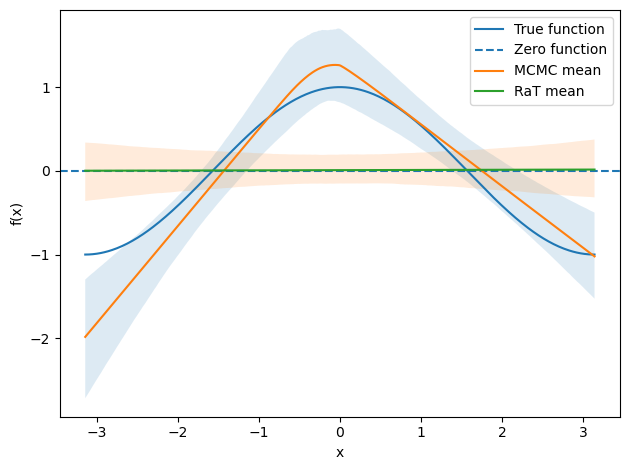

In [10]:
# -----------------------------
# 6. Function posterior plot
# -----------------------------

mcmc_grid = me.predict_draws(
    mcmc_model.decoder, x_grid, mcmc_xi
)
rat_grid = me.predict_draws(
    out["model"].decoder, x_grid, out["final"]["xi"]
)

fig, ax = me.plot_function_1d(
    x=x_grid[:, 0].cpu(),
    signal=signal_grid.cpu(),
    mcmc_pred_draws=mcmc_grid,
    rat_pred_draws=rat_grid,
)

`sigmoid_zero_threshold=0.05` is used only in path diagnostics. Training, ELBO evaluation, and MCMC always use the continuous sigmoid values; no hard truncation is applied to the decoder.